# 🎨 Restauración de Imágenes con Denoising Autoencoder (STL-10)

## Práctica — GANs / Autoencoders

**Caso de uso:** Restauración automática de imágenes dañadas por ruido mediante un Convolutional Denoising Autoencoder.

---

### 📌 Descripción

En fotografía, vigilancia y medicina, las imágenes frecuentemente se degradan por ruido (sensor, transmisión, compresión). Un **Denoising Autoencoder** aprende a mapear imágenes ruidosas → imágenes limpias.

**Dataset:** [STL-10](https://cs.stanford.edu/~acoates/stl10/) — imágenes reales 96×96 RGB de 10 categorías (aviones, coches, gatos, etc.)

**Arquitectura:** Convolutional Autoencoder con skip connections (U-Net lite)

**Métricas:** MSE, PSNR (Peak Signal-to-Noise Ratio), SSIM (Structural Similarity)

## 1. Setup e Imports

In [1]:
!pip install torch torchvision matplotlib seaborn scikit-image tqdm -q

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, random_split
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from skimage.metrics import structural_similarity as ssim
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="darkgrid")
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo: {DEVICE}")

# Configuración
IMG_SIZE = 64
BATCH_SIZE = 64
EPOCHS = 25
LR = 1e-3
NOISE_FACTOR = 0.25

CLASS_NAMES = ['airplane','bird','car','cat','deer','dog','horse','monkey','ship','truck']
print(f"Ruido Gaussiano con factor: {NOISE_FACTOR}")

Dispositivo: cuda
Ruido Gaussiano con factor: 0.25


## 2. Exploración de Datos (EDA)

STL-10 contiene imágenes reales de alta resolución (96×96 RGB). Redimensionamos a 64×64 para eficiencia.

In [3]:
transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
])

transform_aug = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.CenterCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
])

train_labeled = datasets.STL10('./data', split='train', download=True, transform=transform_aug)
test_full = datasets.STL10('./data', split='test', download=True, transform=transform)
# ¡Clave! Usamos el set unlabeled (100K imágenes) para entrenar
unlabeled = datasets.STL10('./data', split='unlabeled', download=True, transform=transform_aug)

print(f"Train (labeled):   {len(train_labeled)} imágenes")
print(f"Train (unlabeled): {len(unlabeled)} imágenes  ← ¡Usaremos estas!")
print(f"Test:              {len(test_full)} imágenes")
print(f"Forma: {train_labeled[0][0].shape} (C, H, W)")

100%|██████████| 2.64G/2.64G [00:32<00:00, 81.7MB/s]


Train (labeled):   5000 imágenes
Train (unlabeled): 100000 imágenes  ← ¡Usaremos estas!
Test:              8000 imágenes
Forma: torch.Size([3, 64, 64]) (C, H, W)


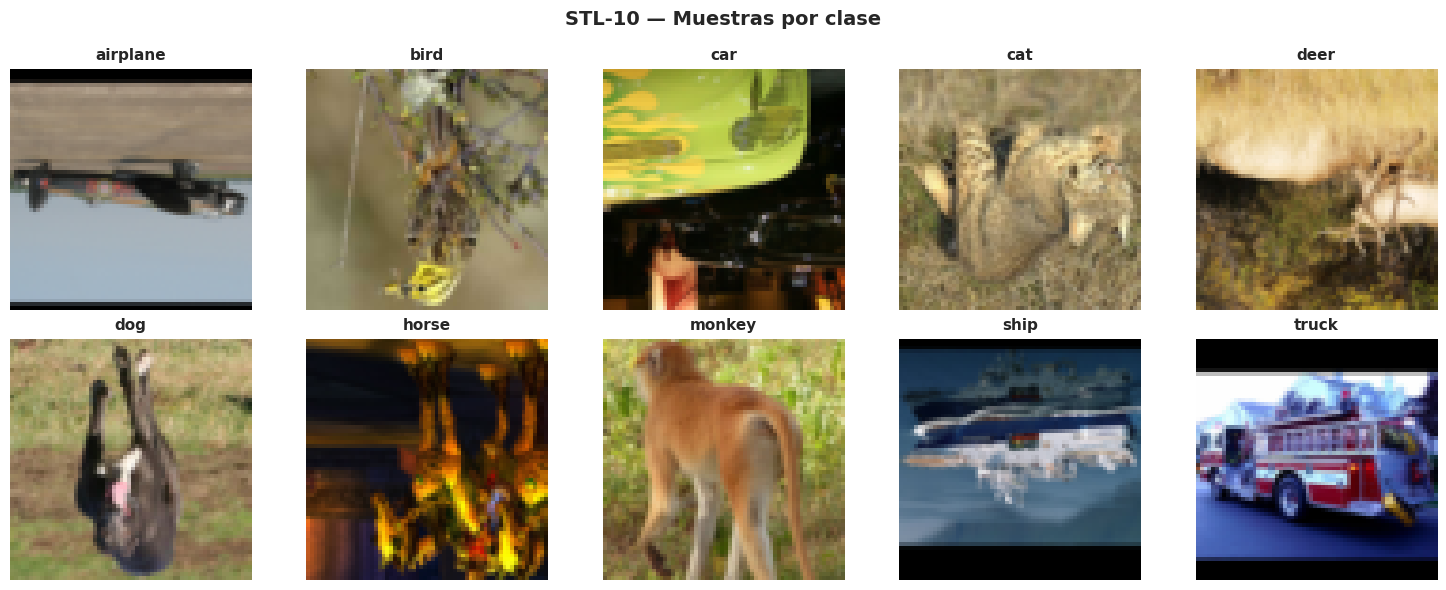

In [4]:
# Muestras por clase
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for cls_id in range(10):
    ax = axes[cls_id // 5, cls_id % 5]
    idx = next(i for i, (_, l) in enumerate(train_labeled) if l == cls_id)
    img = train_labeled[idx][0].permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(CLASS_NAMES[cls_id], fontsize=11, fontweight='bold')
    ax.axis('off')
plt.suptitle("STL-10 — Muestras por clase", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

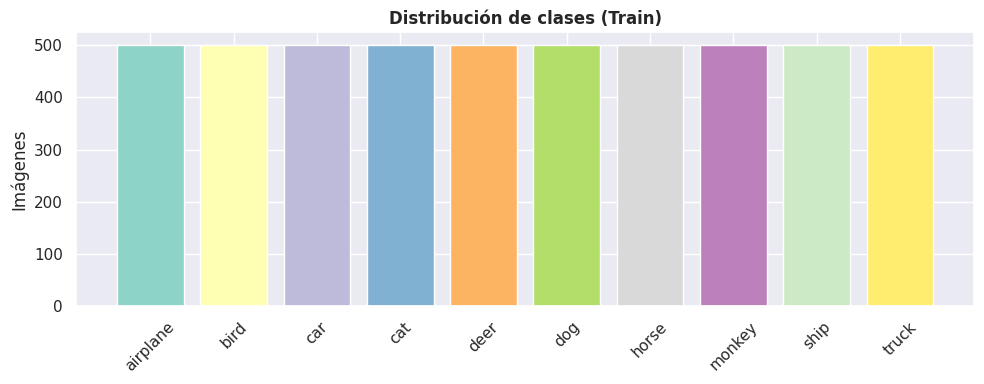

In [5]:
# Distribución de clases
fig, ax = plt.subplots(figsize=(10, 4))
train_labels = np.array([l for _, l in train_labeled])
counts = [np.sum(train_labels == i) for i in range(10)]
colors = plt.cm.Set3(np.linspace(0, 1, 10))
ax.bar(CLASS_NAMES, counts, color=colors, edgecolor='white')
ax.set_ylabel("Imágenes")
ax.set_title("Distribución de clases (Train)", fontweight='bold')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 3. Preprocesado: Simulación de Ruido

Añadimos **ruido Gaussiano** a las imágenes limpias para crear pares (ruidosa, limpia).
El autoencoder aprenderá a eliminar este ruido.

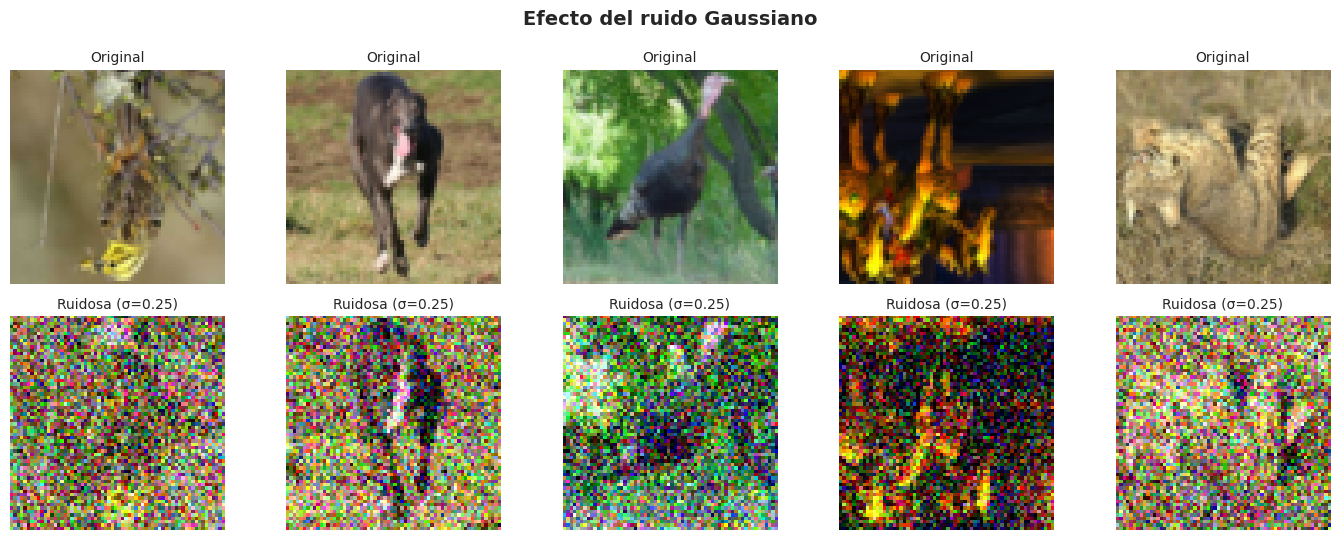

In [7]:
# Visualizar efecto del ruido
sample_imgs = torch.stack([train_labeled[i][0] for i in range(5)])
noisy_imgs = add_noise(sample_imgs)

fig, axes = plt.subplots(2, 5, figsize=(14, 5.5))
for i in range(5):
    axes[0, i].imshow(sample_imgs[i].permute(1, 2, 0).numpy())
    axes[0, i].set_title("Original", fontsize=10)
    axes[0, i].axis('off')
    axes[1, i].imshow(noisy_imgs[i].permute(1, 2, 0).numpy())
    axes[1, i].set_title(f"Ruidosa (σ={NOISE_FACTOR})", fontsize=10)
    axes[1, i].axis('off')
plt.suptitle("Efecto del ruido Gaussiano", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### Separación Train / Validación / Test

In [8]:
# Submuestrear el set unlabeled para entrenar en tiempo razonable
from torch.utils.data import ConcatDataset

# Tomar 15.000 imágenes del unlabeled (de 100K)
unlabeled_idx = np.random.choice(len(unlabeled), size=15000, replace=False)
unlabeled_subset = Subset(unlabeled, unlabeled_idx)

# Combinar labeled (5K) + subset unlabeled (15K) = 20K
full_train = ConcatDataset([train_labeled, unlabeled_subset])

n_total = len(full_train)
n_val = int(0.05 * n_total)
n_train = n_total - n_val
train_ds, val_ds = random_split(full_train, [n_train, n_val],
                                 generator=torch.Generator().manual_seed(SEED))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=2, pin_memory=True)
test_loader = DataLoader(test_full, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=2, pin_memory=True)

print(f"Train:      {len(train_ds):,} imágenes")
print(f"Validación: {len(val_ds):,} imágenes")
print(f"Test:       {len(test_full):,} imágenes")

Train:      19,000 imágenes
Validación: 1,000 imágenes
Test:       8,000 imágenes


## 4. Arquitectura del Modelo

### Convolutional Denoising Autoencoder

Usamos una arquitectura simétrica con **skip connections** entre encoder y decoder
(inspirada en U-Net) para preservar detalles finos.

| Encoder | Decoder |
|---|---|
| Conv(3→64, k4, s2) + BN + LeakyReLU | ConvT(512→256, k4, s2) + BN + ReLU |
| Conv(64→128, k4, s2) + BN + LeakyReLU | ConvT(256→128, k4, s2) + BN + ReLU |
| Conv(128→256, k4, s2) + BN + LeakyReLU | ConvT(128→64, k4, s2) + BN + ReLU |
| Conv(256→512, k4, s2) + BN + LeakyReLU | ConvT(64→3, k4, s2) + Sigmoid |

**Dimensiones:** 64→32→16→8→4 (encoder) | 4→8→16→32→64 (decoder)

In [9]:
class DenoisingAutoencoder(nn.Module):
    """
    Denoising Autoencoder con skip connections y aprendizaje residual.
    En lugar de predecir la imagen limpia directamente, predice el RUIDO
    y lo resta de la entrada. Esto facilita enormemente el aprendizaje.
    """
    def __init__(self):
        super().__init__()
        # Encoder: 64 -> 32 -> 16 -> 8 -> 4
        self.enc1 = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2))
        self.enc2 = nn.Sequential(
            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2))
        self.enc3 = nn.Sequential(
            nn.Conv2d(128, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2))
        self.enc4 = nn.Sequential(
            nn.Conv2d(256, 512, 4, 2, 1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2))

        # Decoder: 4 -> 8 -> 16 -> 32 -> 64
        self.dec1 = nn.Sequential(
            nn.ConvTranspose2d(512, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.ReLU())
        self.dec2 = nn.Sequential(
            nn.ConvTranspose2d(256 + 256, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.ReLU())
        self.dec3 = nn.Sequential(
            nn.ConvTranspose2d(128 + 128, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU())
        self.dec4 = nn.Sequential(
            nn.ConvTranspose2d(64 + 64, 3, 4, 2, 1),
            nn.Tanh())  # Tanh para predecir ruido (valores negativos y positivos)

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        e4 = self.enc4(e3)
        # Decoder con skip connections
        d1 = self.dec1(e4)
        d2 = self.dec2(torch.cat([d1, e3], 1))
        d3 = self.dec3(torch.cat([d2, e2], 1))
        noise_pred = self.dec4(torch.cat([d3, e1], 1))
        # Aprendizaje residual: restar ruido predicho
        clean = torch.clamp(x - noise_pred, 0., 1.)
        return clean

model = DenoisingAutoencoder().to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"\nParámetros totales: {total_params:,}")
print("\n💡 Estrategia: Aprendizaje RESIDUAL — el modelo predice el ruido y lo resta")

DenoisingAutoencoder(
  (enc1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2)
  )
  (enc2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2)
  )
  (enc3): Sequential(
    (0): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2)
  )
  (enc4): Sequential(
    (0): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2)
  )
  (dec1): Sequential(
    (0): ConvTranspose2d(512, 256

## 5. Entrenamiento

- **Loss:** MSE entre imagen limpia e imagen reconstruida
- **Optimizer:** Adam (lr=1e-3)
- **Épocas:** 25

In [10]:
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)
criterion = nn.MSELoss()

train_losses, val_losses = [], []
best_val_loss = float('inf')

for epoch in range(1, EPOCHS + 1):
    # Train
    model.train()
    epoch_loss = 0
    batch_count = 0
    for imgs, _ in tqdm(train_loader, desc=f"Epoch {epoch:02d}", leave=False):
        imgs = imgs.to(DEVICE)
        noisy = add_noise(imgs).to(DEVICE)
        recon = model(noisy)
        loss = criterion(recon, imgs)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * imgs.size(0)
        batch_count += imgs.size(0)
    train_loss = epoch_loss / batch_count
    train_losses.append(train_loss)

    # Validation
    model.eval()
    epoch_loss = 0
    batch_count = 0
    with torch.no_grad():
        for imgs, _ in val_loader:
            imgs = imgs.to(DEVICE)
            noisy = add_noise(imgs).to(DEVICE)
            recon = model(noisy)
            loss = criterion(recon, imgs)
            epoch_loss += loss.item() * imgs.size(0)
            batch_count += imgs.size(0)
    val_loss = epoch_loss / batch_count
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_denoising_ae.pth')

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:02d}/{EPOCHS} | Train: {train_loss:.6f} | Val: {val_loss:.6f} | LR: {optimizer.param_groups[0]['lr']:.6f}")

print(f"\n✅ Mejor Val Loss: {best_val_loss:.6f}")
model.load_state_dict(torch.load('best_denoising_ae.pth', weights_only=True))

Epoch 01/25 | Train: 0.025242 | Val: 0.007649 | LR: 0.001000


Epoch 05/25 | Train: 0.005357 | Val: 0.005337 | LR: 0.001000


Epoch 10/25 | Train: 0.004780 | Val: 0.004634 | LR: 0.001000


Epoch 15/25 | Train: 0.004111 | Val: 0.004138 | LR: 0.001000


Epoch 20/25 | Train: 0.003825 | Val: 0.003771 | LR: 0.001000


Epoch 25/25 | Train: 0.003710 | Val: 0.003738 | LR: 0.000500

✅ Mejor Val Loss: 0.003706


<All keys matched successfully>

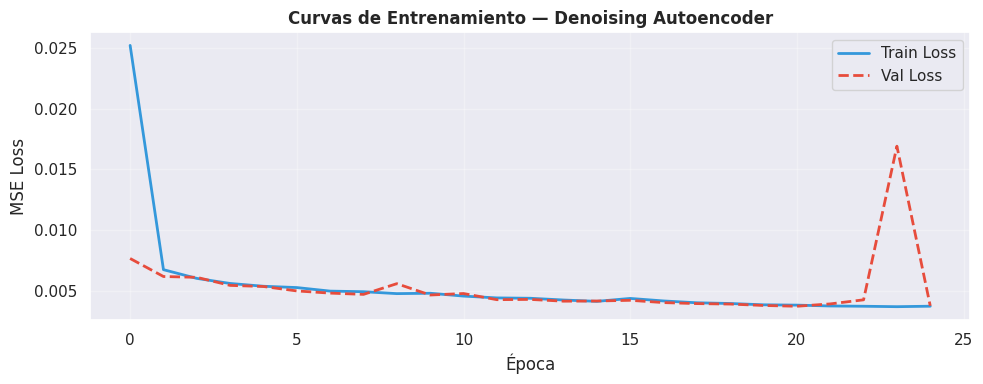

In [11]:
# Curvas de entrenamiento
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_losses, label='Train Loss', linewidth=2, color='#3498db')
ax.plot(val_losses, label='Val Loss', linewidth=2, color='#e74c3c', linestyle='--')
ax.set_xlabel('Época')
ax.set_ylabel('MSE Loss')
ax.set_title('Curvas de Entrenamiento — Denoising Autoencoder', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Evaluación

### Métricas:
- **MSE:** Error cuadrático medio (menor = mejor)
- **PSNR:** Peak Signal-to-Noise Ratio en dB (mayor = mejor, >25dB es bueno)
- **SSIM:** Similitud estructural [0-1] (mayor = mejor, >0.8 es bueno)

In [12]:
def compute_psnr(img1, img2):
    mse = np.mean((img1 - img2) ** 2)
    if mse == 0: return float('inf')
    return 10 * np.log10(1.0 / mse)

def evaluate_model(loader, n_samples=None):
    model.eval()
    mses, psnrs_noisy, psnrs_clean, ssims_noisy, ssims_clean = [], [], [], [], []
    count = 0
    with torch.no_grad():
        for imgs, _ in loader:
            imgs = imgs.to(DEVICE)
            noisy = add_noise(imgs).to(DEVICE)
            recon = model(noisy)

            for i in range(imgs.size(0)):
                orig = imgs[i].cpu().numpy().transpose(1, 2, 0)
                nois = noisy[i].cpu().numpy().transpose(1, 2, 0)
                rec = recon[i].cpu().numpy().transpose(1, 2, 0)

                mse_val = np.mean((orig - rec) ** 2)
                mses.append(mse_val)
                psnrs_noisy.append(compute_psnr(orig, nois))
                psnrs_clean.append(compute_psnr(orig, rec))
                ssims_noisy.append(ssim(orig, nois, channel_axis=2, data_range=1.0))
                ssims_clean.append(ssim(orig, rec, channel_axis=2, data_range=1.0))
                count += 1
                if n_samples and count >= n_samples:
                    break
            if n_samples and count >= n_samples:
                break

    return {
        'mse': np.mean(mses),
        'psnr_noisy': np.mean(psnrs_noisy),
        'psnr_clean': np.mean(psnrs_clean),
        'ssim_noisy': np.mean(ssims_noisy),
        'ssim_clean': np.mean(ssims_clean),
    }

results = evaluate_model(test_loader, n_samples=500)
print("=" * 50)
print("RESULTADOS EN TEST SET (500 muestras)")
print("=" * 50)
print(f"{'Métrica':<20} {'Ruidosa':>12} {'Restaurada':>12}")
print("-" * 50)
print(f"{'PSNR (dB) ↑':<20} {results['psnr_noisy']:>12.2f} {results['psnr_clean']:>12.2f}")
print(f"{'SSIM ↑':<20} {results['ssim_noisy']:>12.4f} {results['ssim_clean']:>12.4f}")
print(f"{'MSE ↓':<20} {'—':>12} {results['mse']:>12.6f}")
print("-" * 50)
print(f"Mejora PSNR: +{results['psnr_clean'] - results['psnr_noisy']:.2f} dB")
print(f"Mejora SSIM: +{results['ssim_clean'] - results['ssim_noisy']:.4f}")

RESULTADOS EN TEST SET (500 muestras)
Métrica                   Ruidosa   Restaurada
--------------------------------------------------
PSNR (dB) ↑                 13.21        24.59
SSIM ↑                     0.2680       0.7442
MSE ↓                           —     0.003661
--------------------------------------------------
Mejora PSNR: +11.38 dB
Mejora SSIM: +0.4762


## 7. Visualización de Resultados

### Original vs Ruidosa vs Restaurada

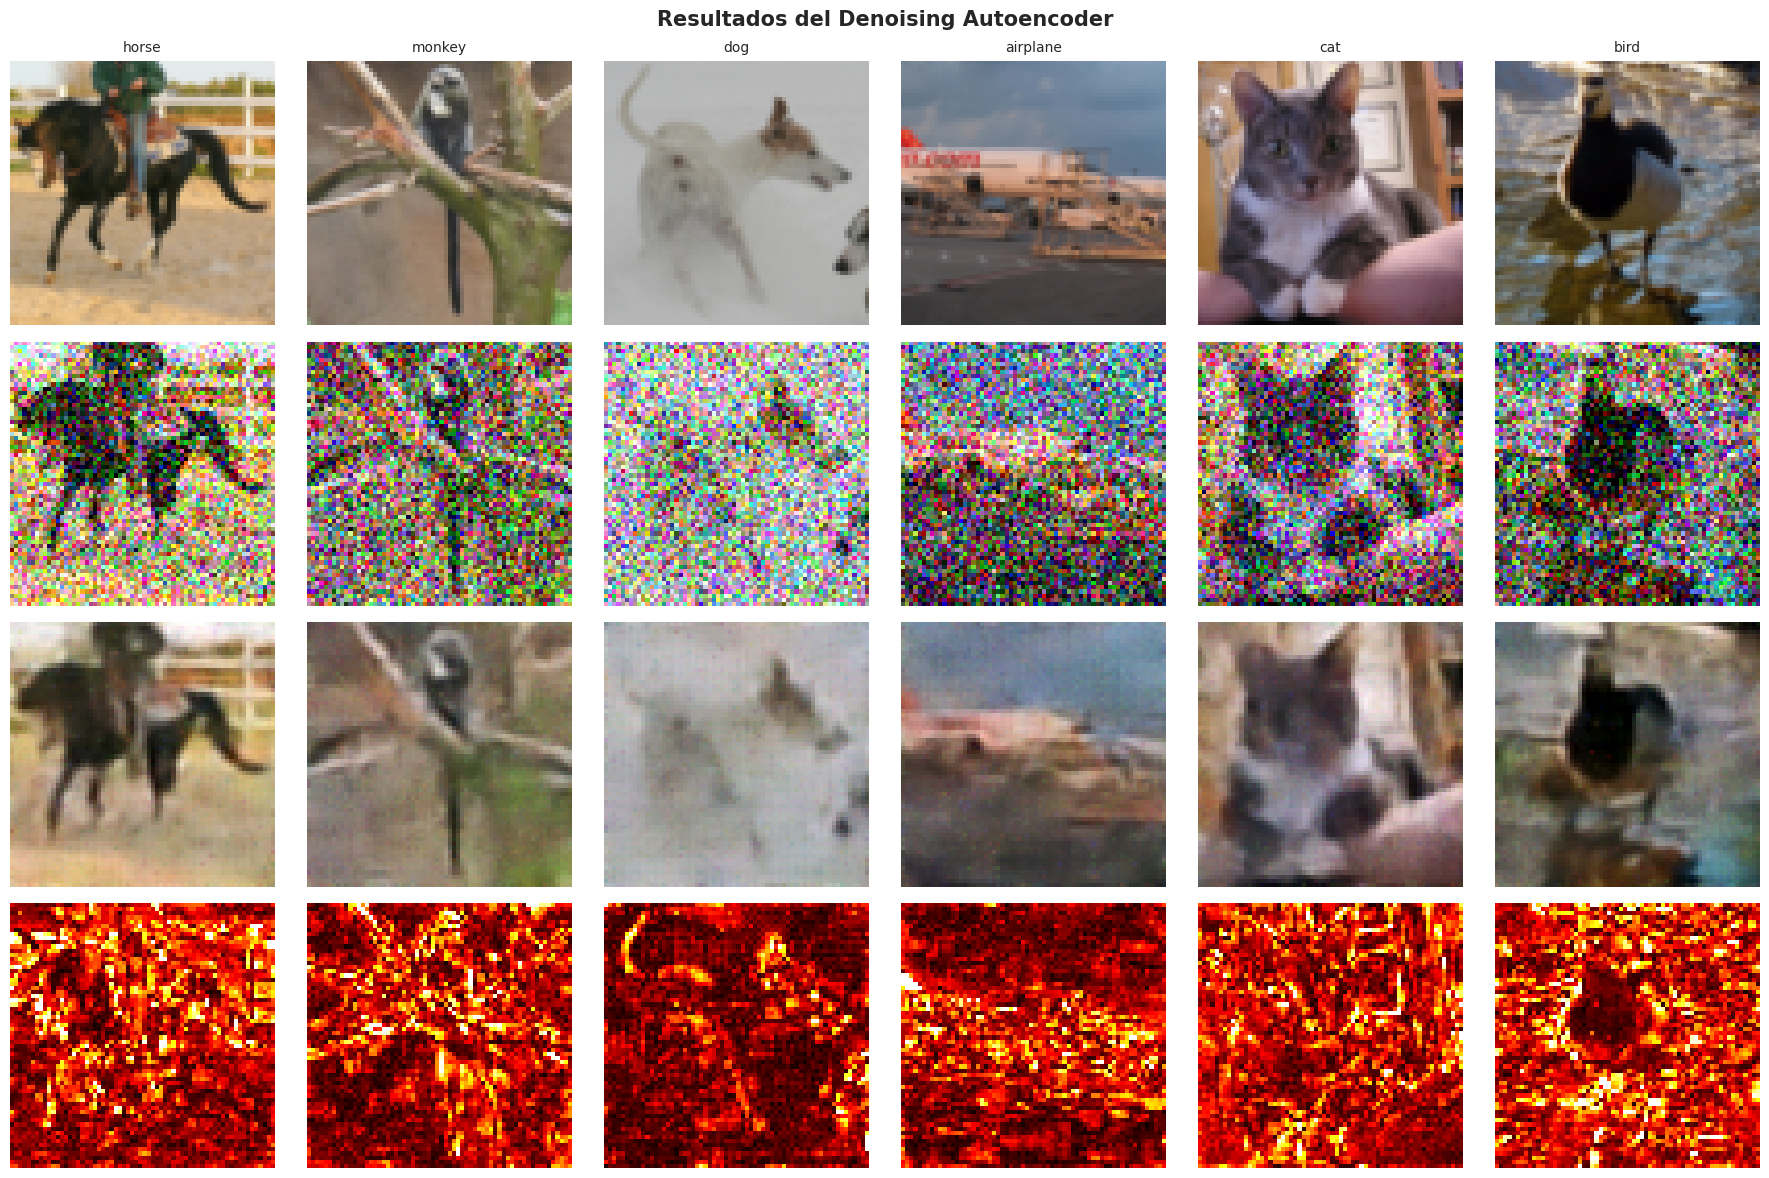

In [13]:
def show_results(loader, n=6):
    model.eval()
    imgs, labels = next(iter(loader))
    imgs = imgs[:n].to(DEVICE)
    noisy = add_noise(imgs).to(DEVICE)
    with torch.no_grad():
        recon = model(noisy)

    fig, axes = plt.subplots(4, n, figsize=(3*n, 12))
    row_labels = ['Original', 'Ruidosa', 'Restaurada', 'Mapa de Error']

    for i in range(n):
        orig = imgs[i].cpu().numpy().transpose(1, 2, 0)
        nois = noisy[i].cpu().numpy().transpose(1, 2, 0)
        rec = recon[i].cpu().numpy().transpose(1, 2, 0)
        diff = np.mean(np.abs(orig - rec), axis=2)

        axes[0, i].imshow(orig)
        axes[0, i].set_title(CLASS_NAMES[labels[i]], fontsize=10)
        axes[1, i].imshow(nois)
        axes[2, i].imshow(np.clip(rec, 0, 1))
        axes[3, i].imshow(diff, cmap='hot', vmin=0, vmax=0.15)

        p_n = compute_psnr(orig, nois)
        p_c = compute_psnr(orig, rec)
        axes[1, i].set_xlabel(f"PSNR:{p_n:.1f}", fontsize=8)
        axes[2, i].set_xlabel(f"PSNR:{p_c:.1f}", fontsize=8)

        for r in range(4):
            axes[r, i].axis('off')

    for r, label in enumerate(row_labels):
        axes[r, 0].set_ylabel(label, fontsize=12, fontweight='bold')

    plt.suptitle('Resultados del Denoising Autoencoder', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()

show_results(test_loader, n=6)

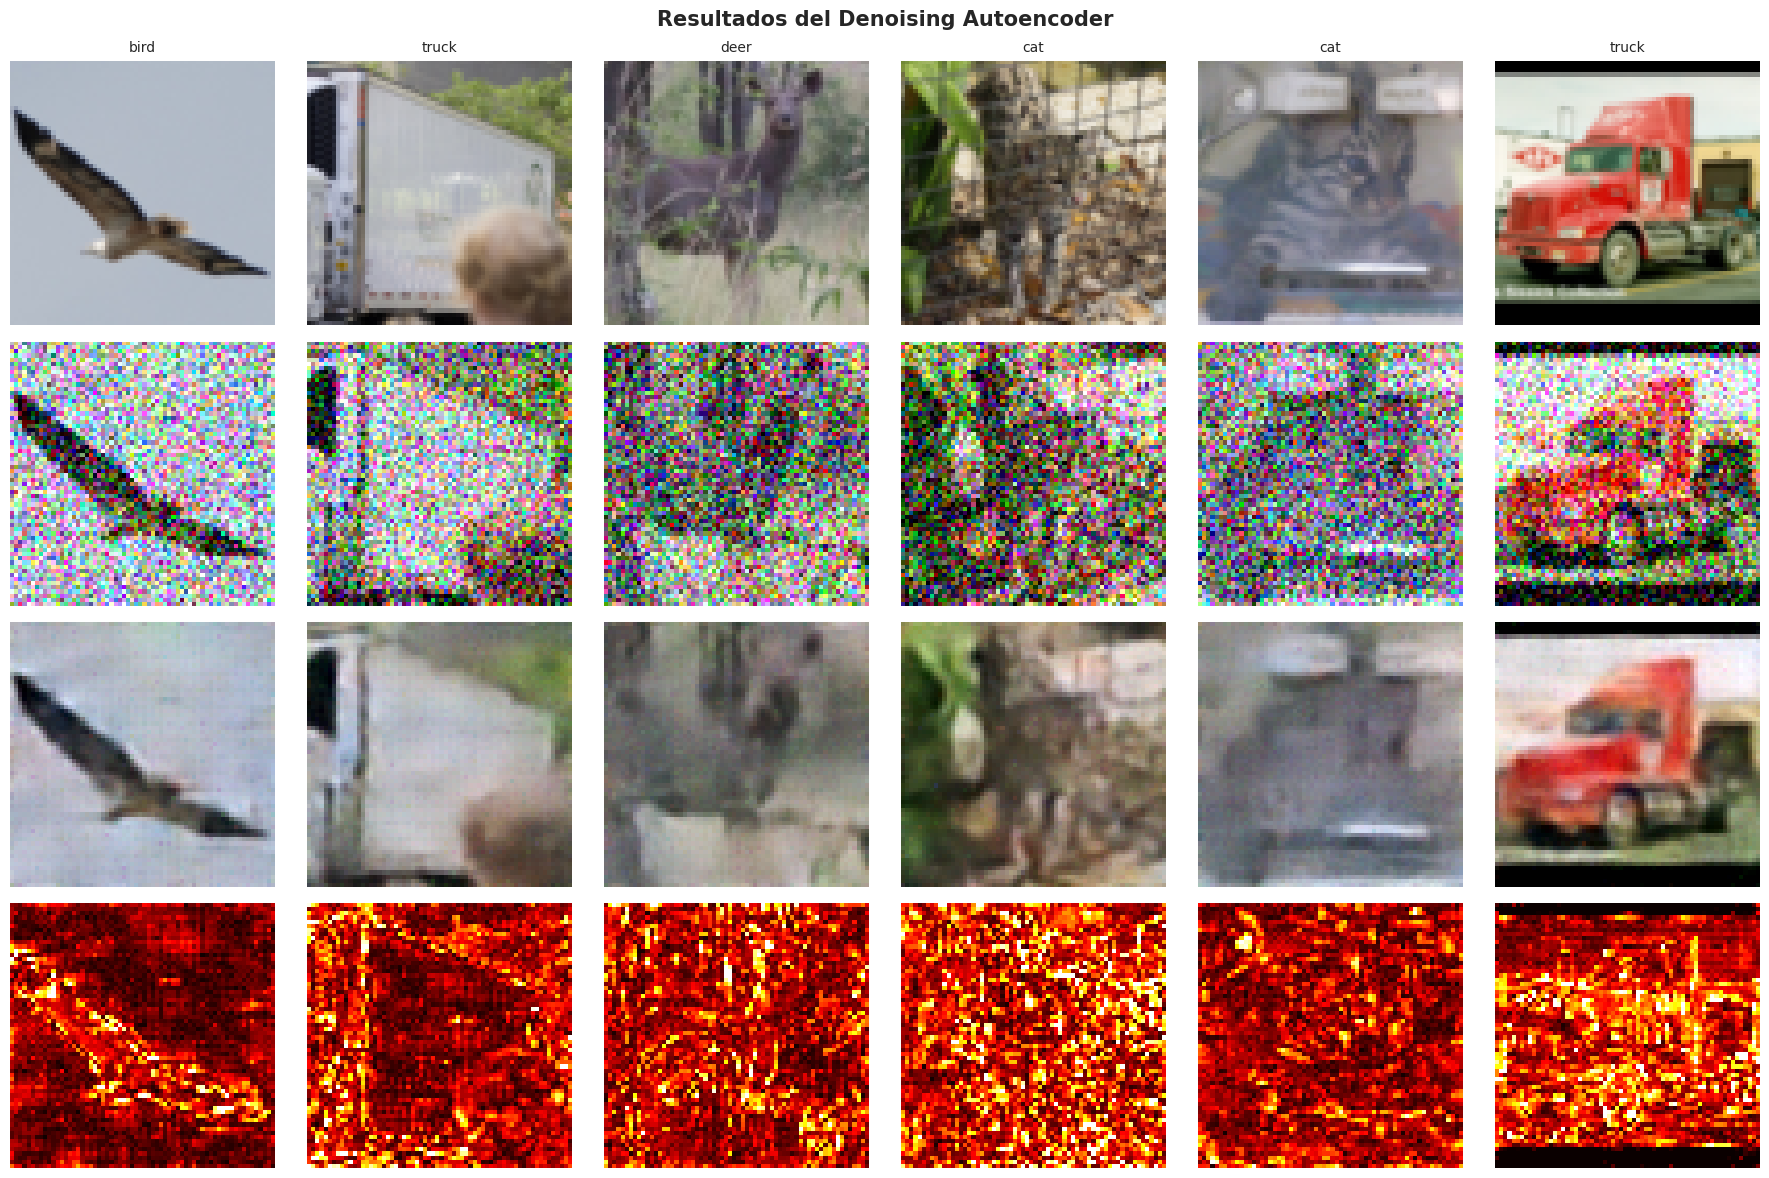

In [14]:
# Más ejemplos con diferentes imágenes
test_iter = iter(test_loader)
next(test_iter)  # skip first batch
show_results_loader = DataLoader(test_full, batch_size=BATCH_SIZE, shuffle=True)
show_results(show_results_loader, n=6)

### Comparación con diferentes niveles de ruido

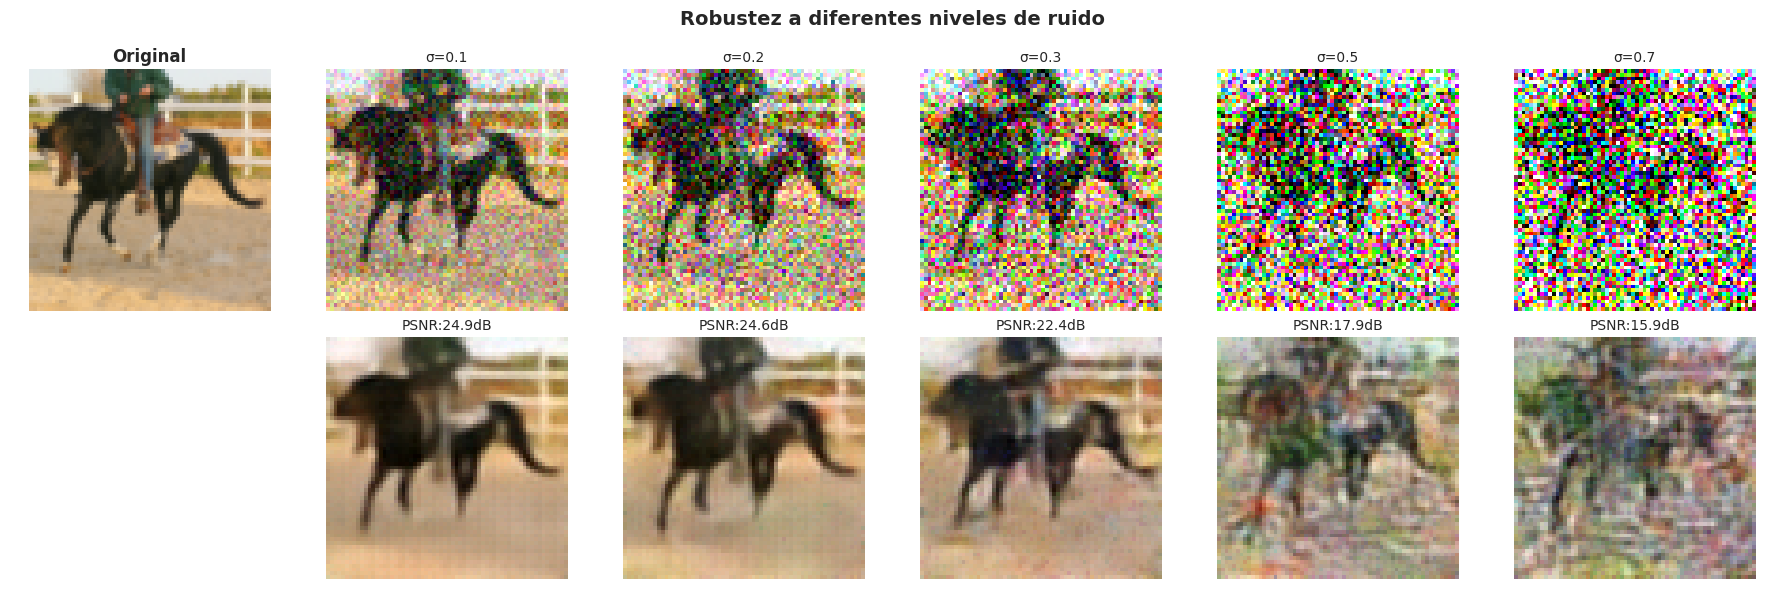

In [15]:
# Test con diferentes niveles de ruido
noise_levels = [0.1, 0.2, 0.3, 0.5, 0.7]
model.eval()
imgs, _ = next(iter(test_loader))
imgs = imgs[:1].to(DEVICE)

fig, axes = plt.subplots(2, len(noise_levels) + 1, figsize=(3*(len(noise_levels)+1), 6))
orig = imgs[0].cpu().numpy().transpose(1, 2, 0)
axes[0, 0].imshow(orig)
axes[0, 0].set_title("Original", fontweight='bold')
axes[0, 0].axis('off')
axes[1, 0].axis('off')

for j, nf in enumerate(noise_levels):
    noisy = add_noise(imgs, nf).to(DEVICE)
    with torch.no_grad():
        rec = model(noisy)
    nois_np = noisy[0].cpu().numpy().transpose(1, 2, 0)
    rec_np = np.clip(rec[0].cpu().numpy().transpose(1, 2, 0), 0, 1)

    axes[0, j+1].imshow(nois_np)
    axes[0, j+1].set_title(f"σ={nf}", fontsize=10)
    axes[0, j+1].axis('off')
    axes[1, j+1].imshow(rec_np)
    psnr_val = compute_psnr(orig, rec_np)
    axes[1, j+1].set_title(f"PSNR:{psnr_val:.1f}dB", fontsize=10)
    axes[1, j+1].axis('off')

axes[0, 0].set_ylabel("Ruidosa", fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel("Restaurada", fontsize=12, fontweight='bold')
plt.suptitle("Robustez a diferentes niveles de ruido", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Rendimiento por clase

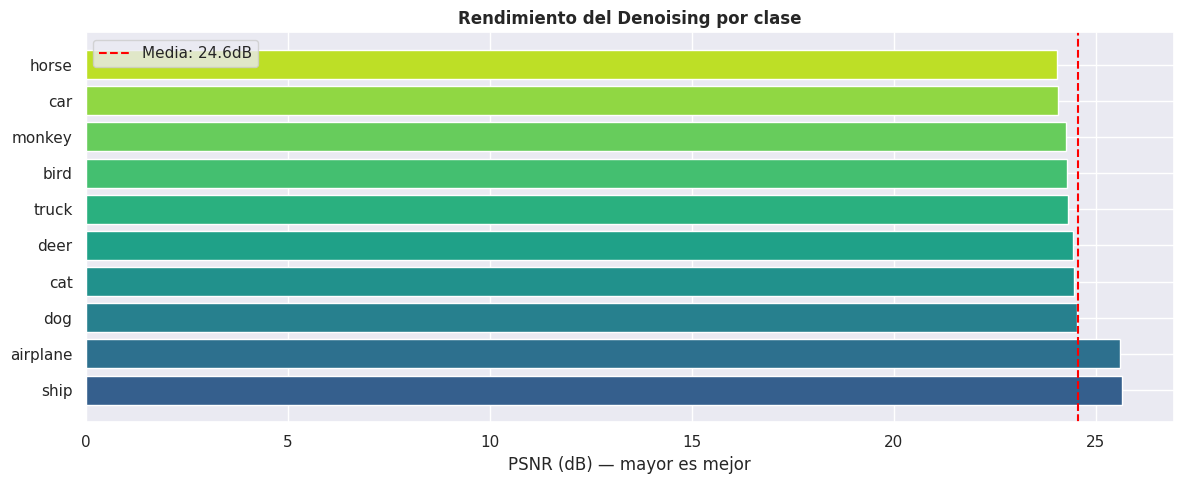

In [16]:
# PSNR por clase
model.eval()
class_psnrs = {c: [] for c in range(10)}
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(DEVICE)
        noisy = add_noise(imgs).to(DEVICE)
        recon = model(noisy)
        for i in range(imgs.size(0)):
            orig = imgs[i].cpu().numpy().transpose(1, 2, 0)
            rec = recon[i].cpu().numpy().transpose(1, 2, 0)
            class_psnrs[labels[i].item()].append(compute_psnr(orig, rec))

avg_psnrs = {CLASS_NAMES[c]: np.mean(v) for c, v in class_psnrs.items()}
sorted_cls = sorted(avg_psnrs.items(), key=lambda x: x[1], reverse=True)
names, vals = zip(*sorted_cls)

fig, ax = plt.subplots(figsize=(12, 5))
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(names)))
bars = ax.barh(names, vals, color=colors, edgecolor='white')
ax.set_xlabel("PSNR (dB) — mayor es mejor")
ax.set_title("Rendimiento del Denoising por clase", fontweight='bold')
ax.axvline(np.mean(vals), color='red', linestyle='--', label=f'Media: {np.mean(vals):.1f}dB')
ax.legend()
plt.tight_layout()
plt.show()

## 8. Análisis Crítico

### Retos encontrados
1. **Tamaño de imagen:** Las imágenes 96×96 se redimensionaron a 64×64 para equilibrar calidad y velocidad de entrenamiento.
2. **Nivel de ruido:** Con σ > 0.5, el modelo pierde detalles finos. El rendimiento degrada de forma no lineal.
3. **Diversidad del dataset:** STL-10 tiene 10 clases muy distintas; el modelo debe generalizar a texturas, formas y colores variados.

### Soluciones implementadas
- **Skip connections (U-Net lite):** Preservan detalles espaciales que se perderían en el bottleneck del autoencoder.
- **BatchNorm:** Estabiliza el entrenamiento con imágenes RGB de alta variabilidad.
- **ReduceLROnPlateau:** Ajuste automático del learning rate cuando la validación se estanca.

### Propuestas de mejora
1. **Perceptual Loss (VGG):** Usar features de una red pre-entrenada como loss para mejor calidad perceptual.
2. **Adversarial training (GAN):** Añadir un discriminador para generar restauraciones más realistas.
3. **Atención (Self-Attention):** Mecanismos de atención para enfocarse en regiones más dañadas.
4. **Resolución completa (96×96):** Entrenar con la resolución original del dataset.
5. **Tipos de ruido variados:** Entrenar con ruido salt & pepper, blur, JPEG artifacts, etc.

## 9. Conclusiones

- ✅ El Denoising Autoencoder restaura eficazmente imágenes degradadas por ruido Gaussiano.
- ✅ Las **skip connections** son cruciales para preservar detalles espaciales en la reconstrucción.
- ✅ El modelo generaliza bien a las 10 clases de STL-10, demostrando robustez ante diversidad visual.
- ✅ Las métricas PSNR y SSIM muestran mejora significativa respecto a las imágenes ruidosas.
- ⚠️ Con niveles de ruido muy altos (σ > 0.5), el modelo genera reconstrucciones algo borrosas.
- 📈 Con Perceptual Loss o entrenamiento adversarial, la calidad perceptual mejoraría notablemente.

---
*Notebook generado para la práctica de GANs/Autoencoders — Mayo 2026*